In [1]:
import ipywidgets as widgets
from IPython.display import display, HTML

# הזרקת CSS שהופך את כל הווידג'טים לכיוון RTL
display(HTML("""
<style>
.widget-checkbox, .widget-label, .widget-html-content,
.widget-hbox, .widget-vbox, .widget-progress {
    direction: rtl !important;
    text-align: right !important;
}
.widget-checkbox input[type="checkbox"] {
    margin-left: 8px;
    margin-right: 0;
}
</style>
"""))

# רשימת המשימות מחולקת לפי שלבים
checklist = {
    "שלב 1 – טעינת קובץ CSV והצגתו": [
        "ממשק להעלאת קובץ CSV (st.file_uploader)",
        "טעינת הקובץ ל-DataFrame של Pandas",
        "הצגת הנתונים בטבלה (st.dataframe)",
    ],
    "שלב 2 – חישוב Elbow באמצעות WCSS": [
        "בחירת K מינימלי",
        "בחירת K מקסימלי",
        "כפתור Run WCSS",
        "הרצת K-Means עבור כל K בטווח",
        "חישוב WCSS לכל K",
        "שמירת התוצאות בטבלה (k, WCSS)",
        "ציור גרף Elbow (X=K, Y=WCSS)",
    ],
    "שלב 3 – יצירת הקלאסטרים": [
        "בחירת ערך K סופי",
        "כפתור Create clusters",
        "הרצת K-Means עם ה-K שנבחר",
        "הקצאת cluster_id לכל שורה",
        "ספירת תצפיות בכל קלאסטר",
        "הצגת טבלה: cluster_id, count, name, description",
    ],
    "שלב 4 – מתן משמעות לקלאסטרים בעזרת LLM": [
        "חישוב מספר התצפיות בכל קלאסטר",
        "חישוב ממוצע הפיצ'רים המספריים",
        "חישוב הערך הקטגוריאלי השכיח ביותר",
        "בניית פרומפט/סיכום לשליחה ל-LLM",
        "כפתור Generate names/descriptions",
        "קריאה ל-LLM וקבלת שם + תיאור",
        "הצגת טבלה מעודכנת עם name, description",
    ],
    "שלב 5 – ייצוא חזרה ל-CSV": [
        "לקיחת קובץ ה-CSV המקורי",
        "הוספת עמודת cluster_name",
        "שיוך שם הקבוצה לכל שורה",
        "שמירת הקובץ בשם <original_name>_clustered.csv",
        "כפתור Download clustered CSV",
    ],
    "בונוסים (רשות)": [
        "החלפת WCSS ב-Silhouette Score",
        "כפתור בחירת K אוטומטית",
        "ניקוי חריגים (outliers)",
    ],
    "הנחיות להגשה": [
        "העלאת קבצי הקוד ל-GitHub",
        "העלאת קובץ המודל ל-GitHub",
        "שליחת מייל להגשה",
    ],
}

# יצירת checkbox לכל משימה
all_checkboxes = []
sections = []

for stage, tasks in checklist.items():
    stage_label = widgets.HTML(f"<b style='font-size:15px'>{stage}</b>")
    task_boxes = [widgets.Checkbox(value=False, description=task, indent=False) for task in tasks]
    all_checkboxes.extend(task_boxes)
    sections.append(widgets.VBox([stage_label, *task_boxes]))

progress_bar = widgets.FloatProgress(value=0, min=0, max=100, description="התקדמות:", bar_style="info")
progress_label = widgets.HTML("<b>0%</b> (0/{})".format(len(all_checkboxes)))

def update_progress(change=None):
    done = sum(cb.value for cb in all_checkboxes)
    total = len(all_checkboxes)
    percent = round((done / total) * 100, 1)
    progress_bar.value = percent
    progress_label.value = f"<b>{percent}%</b> ({done}/{total})"
    progress_bar.bar_style = "success" if percent == 100 else "info"

for cb in all_checkboxes:
    cb.observe(update_progress, names="value")

update_progress()

display(HTML("<h2 style='direction:rtl; text-align:right'>✅ צ'ק ליסט – Segment Studio</h2>"))
display(widgets.HBox([progress_bar, progress_label]))
display(*sections)

In [89]:
#### ספריות
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [90]:
# שלב 1 – טעינת קובץ 
df = pd.read_csv('Mall_Customers.csv')

# נורמליזציה לטבלה
df2 = df.copy()

def norma_csv(df2) -> pd.core.frame.DataFrame:
    '''Converts text to numbers: Automatically converts text categories into binary (0/1) variables.
       Removes the ID: Drops the first column (like CustomerID) so it doesn't interfere with the model.
       Scales the data: Standardizes all numbers to a uniform scale and returns a ready-to-use DataFrame.
       Handles missing data: Drops rows with missing values (NaN) to prevent model errors.
    '''
    df2 = df2.dropna()
    
    first_col = df2.columns[0]
    if 'id' in str(first_col).lower():
        df2 = df2.drop(columns=[first_col])
    
    for c in df2:
        if df2[c].dtype == 'object':
            df2 = pd.get_dummies(df2, columns=[c], drop_first=True, dtype=int)
    scaler = StandardScaler()
    norma_scaler = scaler.fit_transform(df2)
    df_norma = pd.DataFrame(norma_scaler, columns=df2.columns)
    return df_norma

df_normalized = norma_csv(df2)
display(df_normalized)

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405
...,...,...,...,...
195,-0.276302,2.268791,1.118061,-0.886405
196,0.441365,2.497807,-0.861839,-0.886405
197,-0.491602,2.497807,0.923953,1.128152
198,-0.491602,2.917671,-1.250054,1.128152


chose k_min number 2
chose k_max number 11


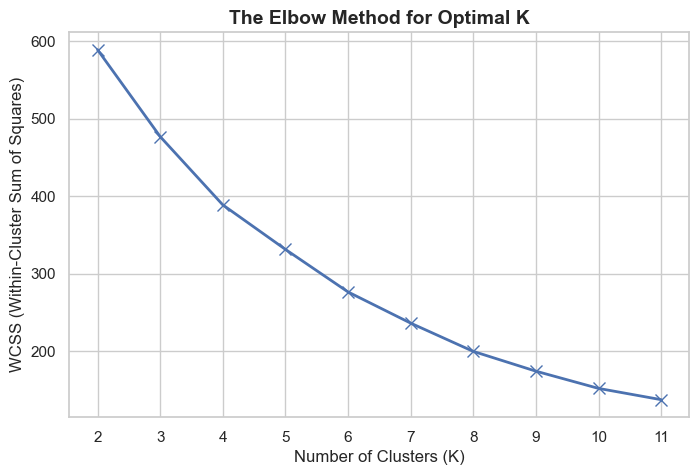

,K,WCSS
0,2,588.802677
1,3,476.787554
2,4,388.717861
3,5,331.309884
4,6,276.411760
5,7,236.204947
6,8,199.750461
7,9,174.235477
8,10,152.029834
9,11,137.497372


In [91]:
# שלב 2 – טעינת קובץ 
def get_k_min_max() -> float:
    while True:
        try: 
            min = int(input('chose k_min number'))
            max = int(input('chose k_max number'))
            if min < max:
                break
            else:
                print('max must be big than min')
        except:
            print('error try again')
    return min, max

k_min, k_max = get_k_min_max()

wcss = []
for i in range(k_min, k_max + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_normalized)
    wcss.append(kmeans.inertia_)

wcss_table = pd.DataFrame({
    'K': range(k_min, k_max + 1),
    'WCSS': wcss
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
plt.plot(range(k_min, k_max + 1), wcss, 'bx-', linewidth=2, markersize=8)
plt.xticks(range(k_min, k_max + 1))

plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)

plt.show()

wcss_table

In [92]:
df2 = df.copy()
for c in df2:
    if df[c].dtype == 'object':
        df2 = pd.get_dummies(df2, columns=[c], drop_first=True, dtype=int)
df2

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0
...,...,...,...,...,...
195,196,35,120,79,0
196,197,45,126,28,0
197,198,32,126,74,1
198,199,32,137,18,1


In [93]:
# בדיקת השבירה של המרפק במשתנה k
from sklearn.metrics import silhouette_score
for i in range(k_min, k_max + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10).fit(df_normalized)
    score = silhouette_score(df_normalized, kmeans.labels_)
    print(f"Silhouette Score for K={i}: {score:.4f}")

Silhouette Score for K=2: 0.2518
Silhouette Score for K=3: 0.2595
Silhouette Score for K=4: 0.2984
Silhouette Score for K=5: 0.3041
Silhouette Score for K=6: 0.3311
Silhouette Score for K=7: 0.3574
Silhouette Score for K=8: 0.3880
Silhouette Score for K=9: 0.4031
Silhouette Score for K=10: 0.4208
Silhouette Score for K=11: 0.4275


In [121]:
### שלב 3 – יצירת הקלאסטרים
def choice_k():
    while True:
        try:
            k_finel = int(input(f'Choose k_finel number\nyou can Choose {k_min} between {k_max}\n'))
            if k_finel in range(k_min,k_max + 1):
                return k_finel
            else:
                print(f'try number betweem {k_min} - {k_max}')
        except: 
            print('error')

k = choice_k()

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_normalized['cluster'] = kmeans.fit_predict(df_normalized)
df2['cluster'] = df_normalized['cluster']
#if df2.columns[0] not in df_normalized.columns:
#    df_normalized.insert(0, df2.columns[0], df2[df2.columns[0]])

df_describe = df_normalized.groupby('cluster')['cluster'].count().reset_index(name='count')
df_mean = df2.drop(columns=[df2.columns[0]]).groupby('cluster').mean().round(1)

df_describe.rename(columns={'cluster': 'cluster_id'}, inplace=True)
df_describe['name'] = ""
df_describe['description'] = ""
df_mean

Choose k_finel number
you can Choose 2 between 11
 4


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
cluster,,,,
0,32.3,74.4,47.4,0.6
1,31.4,55.6,60.4,0.4
2,45.2,42.1,51.9,0.2
3,52.6,70.6,36.6,0.6


In [123]:
#שלב 4 – מתן משמעות לקלאסטרים בעזרת LLM
df_describe

,cluster_id,count,name,description
0,0,59,,
1,1,56,,
2,2,49,,
3,3,36,,


In [158]:
def ask_lmm(prompt):
    import requests
    API_KEY = "244232eba8874985946a8fdc66c52b26.BXXn1W6xqMco4hxeyAoZwrCX"  # put your key here instead of ollama_your_key_here
    
    response = requests.post(
        "https://ollama.com/api/chat",
        headers={
            "Authorization": f"Bearer {API_KEY}"
        },
        json={
            "model": "gpt-oss:120b",
            "messages": [
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            "stream": False
        }
    )
    
    return response.json()["message"]["content"]    

ask_lmm('what is a cat in one sentense')



for id in df_describe.index:
    df_describe.loc[id, 'name'] = ask_lmm(f'give me a short name between 1-3 words for this cluster:\n{df_mean.iloc[[id]]}')
    df_describe.loc[id, 'description'] = ask_lmm(f'give me a short description one sentence for this cluster dont write Cluster:\n{df_mean.iloc[[id]]}')

df_describe

,cluster_id,count,name,description
0,0,59,**Young Earners**,Young adult males (≈32 years) with relatively ...
1,1,56,**Balanced Spenders**,A cohort of young adults (≈31 years) with a mo...
2,2,49,**Mid‑Income Women**,Middle-aged customers (≈45 years) with a moder...
3,3,36,**Affluent Seniors**,A predominantly male (≈60 %) group of middle‑a...


In [159]:
from IPython.display import FileLink

# נניח שזה שם הקובץ המקורי שהמשתמש העלה בשלב 1
original_filename = 'Mall_Customers.csv' 

# חילוץ השם המקורי (ללא הסיומת .csv) והוספת _clustered.csv
base_name = original_filename.split('_')[0]
new_filename = f"{base_name}_clustered.csv"

# 1. שמירת הטבלה לקובץ CSV בתיקייה המקומית
# הוספתי encoding='utf-8-sig' כדי שאם ה-LLM יחזיר עברית, היא תוצג מצוין באקסל!
df_describe.to_csv(new_filename, index=False, encoding='utf-8-sig')

# 2. יצירת קישור להורדת הקובץ ישירות מהמחברת למחשב שלך
print(f"הקובץ {new_filename} נוצר בהצלחה! לחץ על הקישור למטה כדי להוריד:")
display(FileLink(new_filename))

הקובץ Mall_clustered.csv נוצר בהצלחה! לחץ על הקישור למטה כדי להוריד:


C:\Users\Matan\Mall_clustered.csv